# Hybrid Quantum-Classical EEG Epilepsy Classification

This notebook implements a hybrid quantum-classical method for classifying pediatric EEG signals to detect epilepsy disorders. The approach combines:
- Convolutional Neural Networks (CNN) for feature extraction from topographic maps
- Quantum Support Vector Machine (QSVM) for classification
- Traditional SVM for comparison

In [4]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import tensorflow as tf
from tensorflow.keras import layers, models
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## 1. Data Loading and Preprocessing

In [5]:
# Load the dataset
data = pd.read_csv('Epileptic Seizure Recognition.csv')

# Display basic information about the dataset
print("Dataset Shape:", data.shape)
print("\nFirst few rows:")
print(data.head())

# Check for missing values
print("\nMissing values:", data.isnull().sum().sum())

# Separate features and target
X = data.drop(columns=['Unnamed', 'y'], errors='ignore')
y = data['y']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Dataset Shape: (11500, 180)

First few rows:
      Unnamed   X1   X2   X3   X4   X5   X6   X7   X8   X9  ...  X170  X171  \
0  X21.V1.791  135  190  229  223  192  125   55   -9  -33  ...   -17   -15   
1  X15.V1.924  386  382  356  331  320  315  307  272  244  ...   164   150   
2     X8.V1.1  -32  -39  -47  -37  -32  -36  -57  -73  -85  ...    57    64   
3   X16.V1.60 -105 -101  -96  -92  -89  -95 -102 -100  -87  ...   -82   -81   
4   X20.V1.54   -9  -65  -98 -102  -78  -48  -16    0  -21  ...     4     2   

   X172  X173  X174  X175  X176  X177  X178  y  
0   -31   -77  -103  -127  -116   -83   -51  4  
1   146   152   157   156   154   143   129  1  
2    48    19   -12   -30   -35   -35   -36  5  
3   -80   -77   -85   -77   -72   -69   -65  5  
4   -12   -32   -41   -65   -83   -89   -73  5  

[5 rows x 180 columns]

Missing values: 0

Feature matrix shape: (11500, 178)
Target vector shape: (11500,)


## 2. Exploratory Data Analysis

Class Distribution:
Class 1: 2300 samples
Class 2: 2300 samples
Class 3: 2300 samples
Class 4: 2300 samples
Class 5: 2300 samples


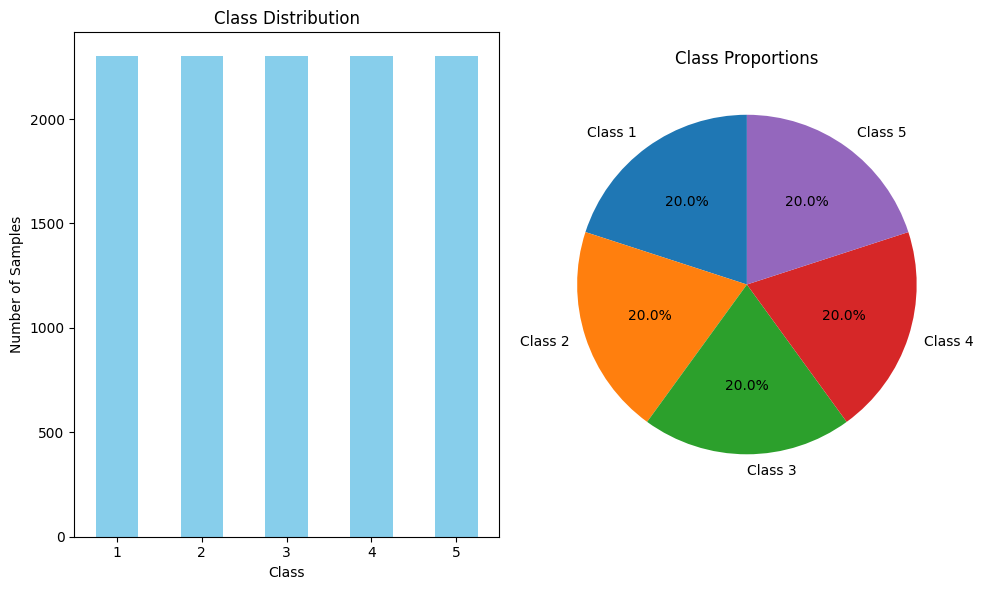

In [6]:
# Class distribution analysis
class_counts = y.value_counts().sort_index()
print("Class Distribution:")
for class_label, count in class_counts.items():
    print(f"Class {class_label}: {count} samples")

# Visualize class distribution
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
class_counts.plot(kind='bar', color='skyblue')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)

# Pie chart for class proportions
plt.subplot(1, 2, 2)
plt.pie(class_counts.values, labels=[f'Class {i}' for i in class_counts.index], 
        autopct='%1.1f%%', startangle=90)
plt.title('Class Proportions')
plt.tight_layout()
plt.show()

Feature Statistics:
                 X1            X2            X3            X4            X5  \
count  11500.000000  11500.000000  11500.000000  11500.000000  11500.000000   
mean     -11.581391    -10.911565    -10.187130     -9.143043     -8.009739   
std      165.626284    166.059609    163.524317    161.269041    160.998007   
min    -1839.000000  -1838.000000  -1835.000000  -1845.000000  -1791.000000   
25%      -54.000000    -55.000000    -54.000000    -54.000000    -54.000000   
50%       -8.000000     -8.000000     -7.000000     -8.000000     -8.000000   
75%       34.000000     35.000000     36.000000     36.000000     35.000000   
max     1726.000000   1713.000000   1697.000000   1612.000000   1518.000000   

                 X6            X7           X8           X9           X10  \
count  11500.000000  11500.000000  11500.00000  11500.00000  11500.000000   
mean      -7.003478     -6.502087     -6.68713     -6.55800     -6.168435   
std      161.328725    161.467837    

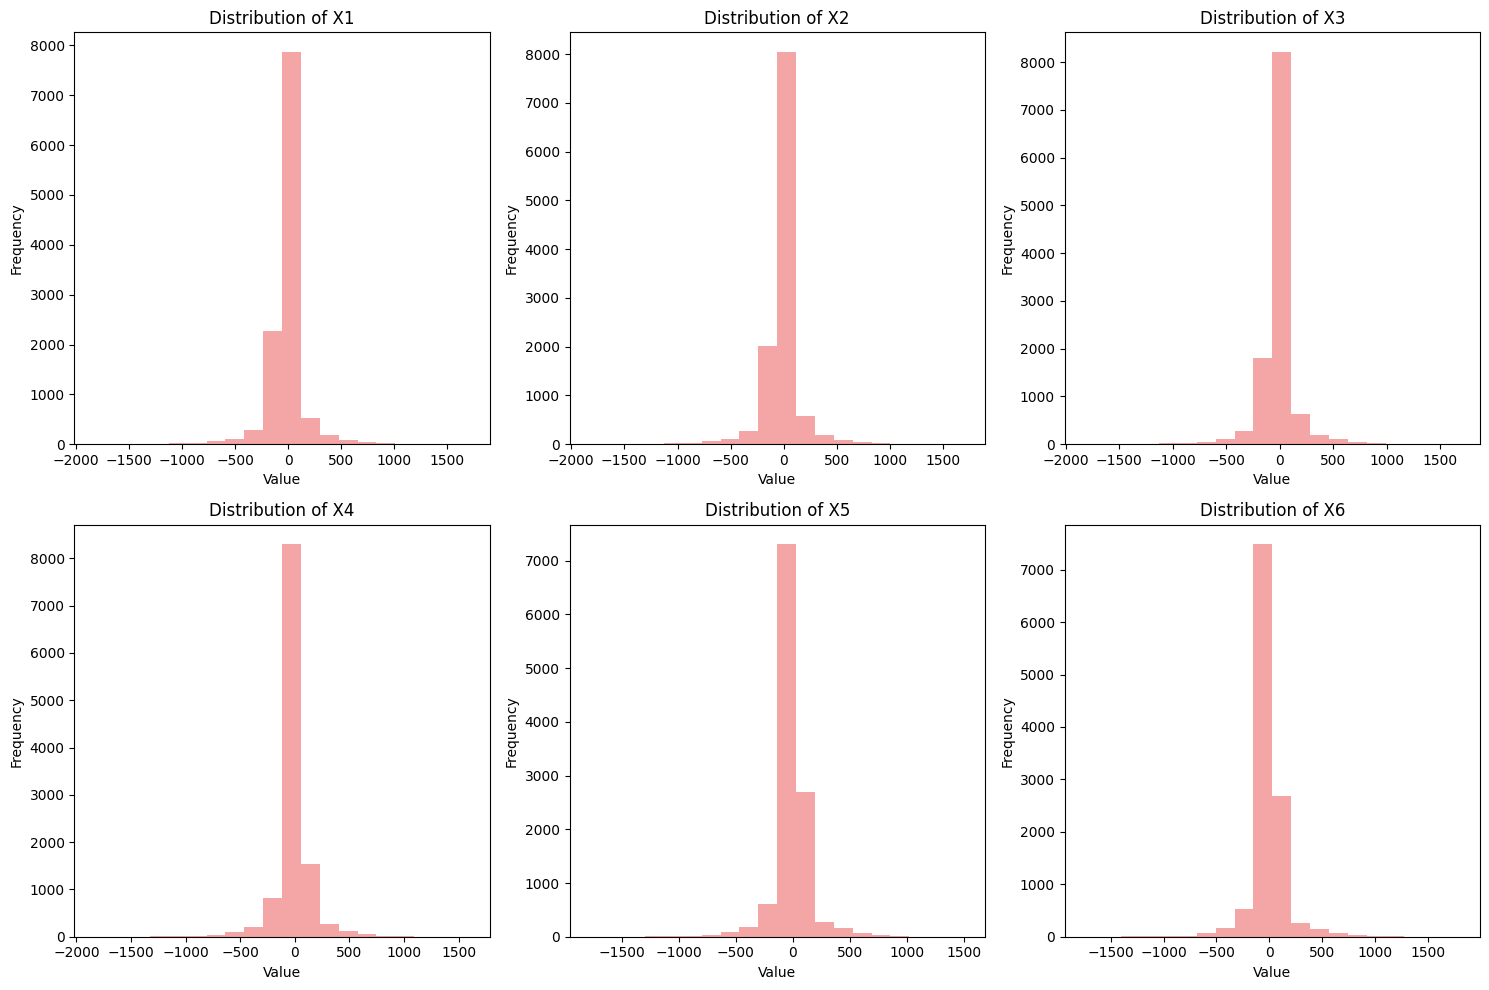

In [7]:
# Statistical summary of features
print("Feature Statistics:")
print(X.describe())

# Visualize feature distributions for first few features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, ax in enumerate(axes.flat):
    if i < len(X.columns[:6]):
        feature = X.columns[i]
        ax.hist(X[feature], bins=20, alpha=0.7, color='lightcoral')
        ax.set_title(f'Distribution of {feature}')
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
    else:
        ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Advanced Preprocessing and Feature Engineering

In [8]:
# Create topographic map representation (simulated)
def create_topographic_features(eeg_data, map_size=(8, 8)):
    """
    Simulate conversion of EEG signals to topographic map features
    In practice, this would use actual electrode positions and interpolation
    """
    n_samples, n_features = eeg_data.shape
    
    # Reshape features into topographic maps
    maps = []
    for i in range(n_samples):
        # Simulate different frequency bands (delta, theta, alpha, beta, gamma)
        bands = np.array_split(eeg_data.iloc[i].values, 5)
        
        # Create 5-channel topographic map
        topo_map = np.zeros((map_size[0], map_size[1], 5))
        
        for band_idx, band in enumerate(bands):
            # Reshape band data to map size
            band_resized = np.resize(band, map_size)
            topo_map[:, :, band_idx] = band_resized
        
        maps.append(topo_map)
    
    return np.array(maps)

# Generate topographic maps
topo_maps = create_topographic_features(X)
print(f"Topographic maps shape: {topo_maps.shape}")

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
n_classes = len(np.unique(y_encoded))
print(f"Number of classes: {n_classes}")

Topographic maps shape: (11500, 8, 8, 5)
Number of classes: 5


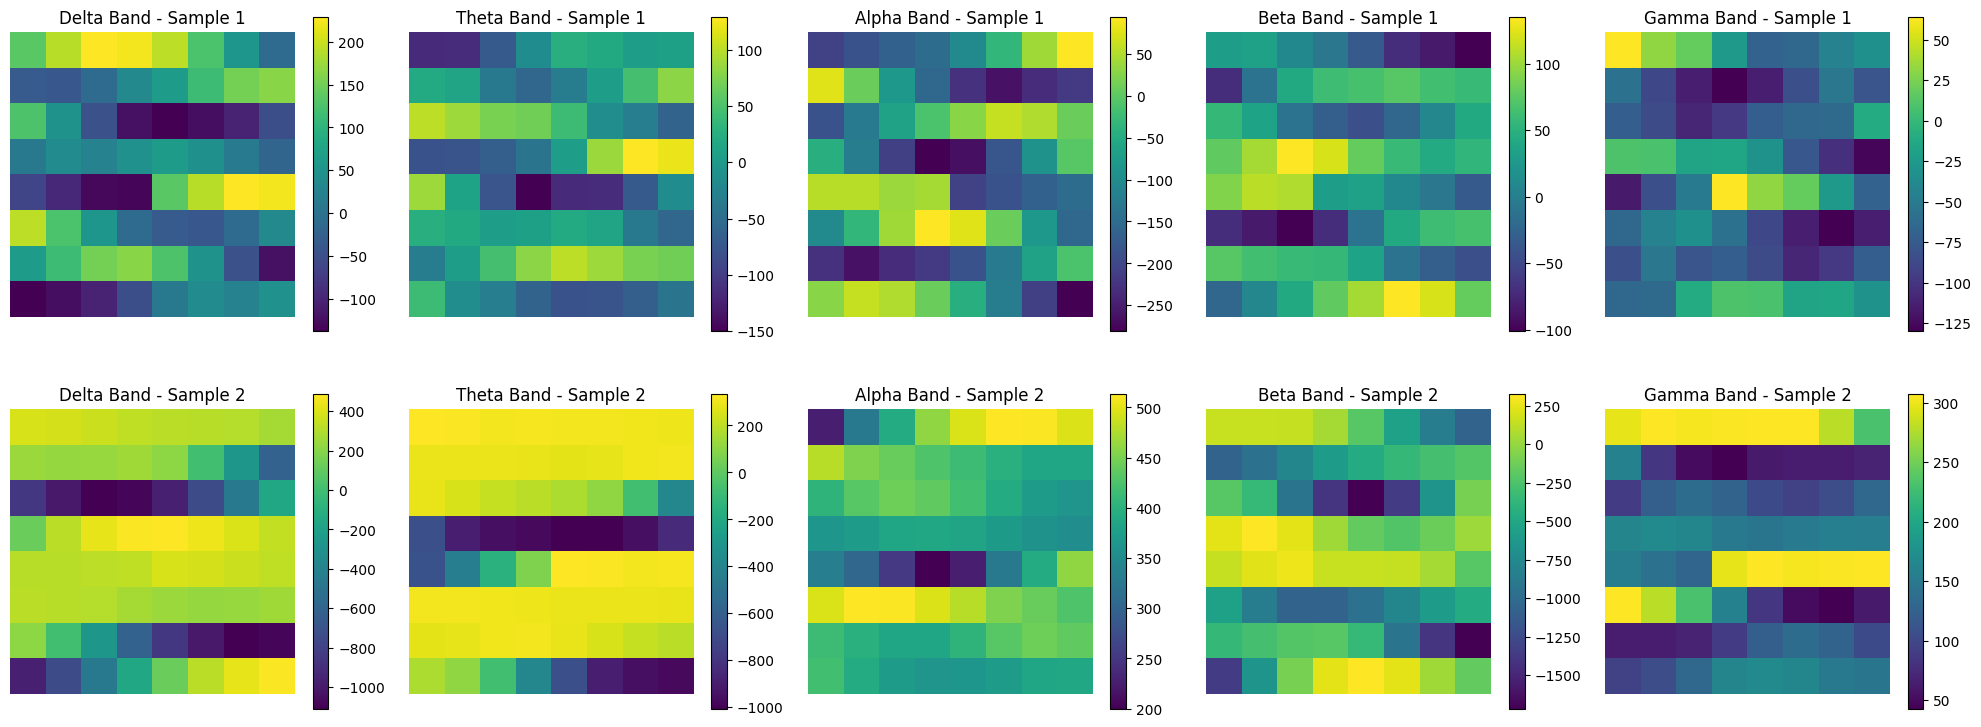

In [9]:
# Visualize sample topographic maps
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
sample_idx = 0
band_names = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']

for band in range(5):
    # Plot original sample
    im1 = axes[0, band].imshow(topo_maps[sample_idx, :, :, band], cmap='viridis')
    axes[0, band].set_title(f'{band_names[band]} Band - Sample 1')
    axes[0, band].axis('off')
    plt.colorbar(im1, ax=axes[0, band], shrink=0.8)
    
    # Plot another sample if available
    if len(topo_maps) > 1:
        im2 = axes[1, band].imshow(topo_maps[1, :, :, band], cmap='viridis')
        axes[1, band].set_title(f'{band_names[band]} Band - Sample 2')
        axes[1, band].axis('off')
        plt.colorbar(im2, ax=axes[1, band], shrink=0.8)

plt.tight_layout()
plt.show()

## 4. Dimensionality Reduction and Visualization

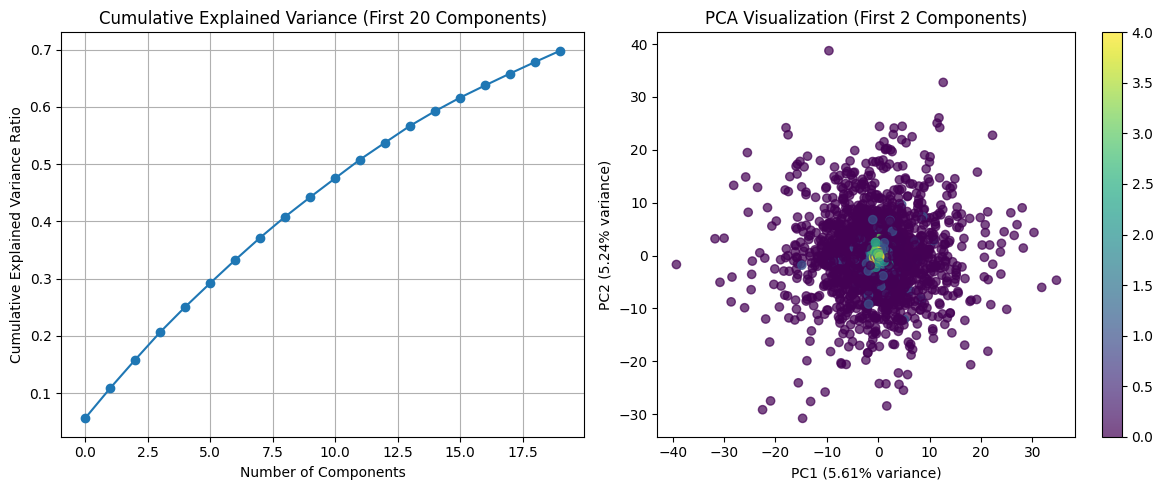

First 10 components explain 44.21% of variance


In [10]:
# PCA Analysis
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Plot explained variance ratio
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(np.cumsum(pca.explained_variance_ratio_[:20]), marker='o')
plt.title('Cumulative Explained Variance (First 20 Components)')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)

# 2D PCA visualization
plt.subplot(1, 2, 2)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_encoded, cmap='viridis', alpha=0.7)
plt.colorbar(scatter)
plt.title('PCA Visualization (First 2 Components)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')

plt.tight_layout()
plt.show()

print(f"First 10 components explain {np.sum(pca.explained_variance_ratio_[:10]):.2%} of variance")

## 5. Convolutional Neural Network for Feature Extraction

In [11]:
# CNN Model for feature extraction from topographic maps
def create_cnn_feature_extractor(input_shape, n_classes):
    model = models.Sequential([
        # First convolutional block
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        # Second convolutional block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        # Third convolutional block
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        
        # Global average pooling for feature extraction
        layers.GlobalAveragePooling2D(),
        
        # Dense layers for classification
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(32, activation='relu', name='feature_layer'),
        layers.Dense(n_classes, activation='softmax')
    ])
    
    return model

# Create and compile the model
input_shape = topo_maps.shape[1:]
cnn_model = create_cnn_feature_extractor(input_shape, n_classes)

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 8, 8, 32)       │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 2, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,221 (411.02 KB)

 Trainable params: 104,773 (409.27 KB)

 Non-trainable params: 448 (1.75 KB)

Augmented dataset shape: (46000, 8, 8, 5)
Epoch 1/50
8050/8050 ━━━━━━━━━━━━━━━━━━━━ 59s 7ms/step - accuracy: 0.5385 - loss: 1.0268 - val_accuracy: 0.5725 - val_loss: 0.9359
Epoch 2/50
8050/8050 ━━━━━━━━━━━━━━━━━━━━ 56s 7ms/step - accuracy: 0.5525 - loss: 0.9749 - val_accuracy: 0.4587 - val_loss: 1.1868
Epoch 3/50
8050/8050 ━━━━━━━━━━━━━━━━━━━━ 56s 7ms/step - accuracy: 0.5719 - loss: 0.9346 - val_accuracy: 0.5595 - val_loss: 0.9400
Epoch 4/50
8050/8050 ━━━━━━━━━━━━━━━━━━━━ 60s 8ms/step - accuracy: 0.5784 - loss: 0.9070 - val_accuracy: 0.5701 - val_loss: 0.8837
Epoch 5/50
8050/8050 ━━━━━━━━━━━━━━━━━━━━ 82s 8ms/step - accuracy: 0.5916 - loss: 0.8768 - val_accuracy: 0.5938 - val_loss: 0.8921
Epoch 6/50
8050/8050 ━━━━━━━━━━━━━━━━━━━━ 79s 7ms/step - accuracy: 0.6002 - loss: 0.8508 - val_accuracy: 0.5766 - val_loss: 0.9154
Epoch 7/50
8050/8050 ━━━━━━━━━━━━━━━━━━━━ 56s 7ms/step - accuracy: 0.6077 - loss: 0.8288 - val_accuracy: 0.6007 - val_loss: 0.8340
Epoch 8/50
8050/8050 ━━━━━━━━━━━━━━━━━━━━

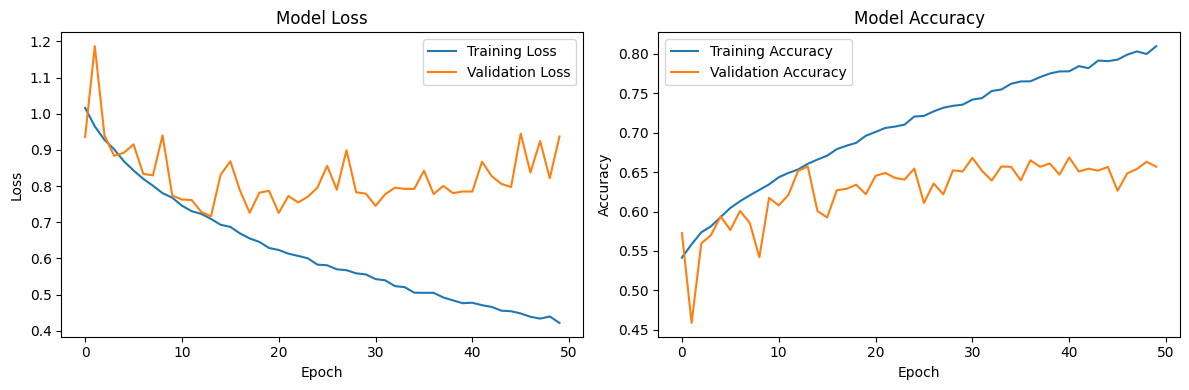

In [15]:
# Train the CNN model
# Note: Due to small dataset, we'll use all data for training and create synthetic validation

# Add some noise to create additional training samples
def augment_data(X, y, noise_factor=0.1, n_augment=3):
    X_aug = [X]
    y_aug = [y]
    
    for i in range(n_augment):
        noise = np.random.normal(0, noise_factor * np.std(X), X.shape)
        X_noisy = X + noise
        X_aug.append(X_noisy)
        y_aug.append(y)
    
    return np.vstack(X_aug), np.hstack(y_aug)

# Augment topographic maps
topo_maps_aug, y_encoded_aug = augment_data(topo_maps, y_encoded)
print(f"Augmented dataset shape: {topo_maps_aug.shape}")

# Split augmented data
X_train_topo, X_test_topo, y_train_topo, y_test_topo = train_test_split(
    topo_maps_aug, y_encoded_aug, test_size=0.3, random_state=42, stratify=y_encoded_aug
)

# Train the CNN
history = cnn_model.fit(
    X_train_topo, y_train_topo,
    epochs=50,
    batch_size=4,
    validation_data=(X_test_topo, y_test_topo),
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
print(cnn_model)

<Sequential name=sequential, built=True>


## 6. CNN Feature Extraction

In [19]:
# Build model (force build)
cnn_model.build((None,) + topo_maps.shape[1:])

# Create feature extractor using .inputs instead of .input
feature_extractor = models.Model(
    inputs=cnn_model.inputs,
    outputs=cnn_model.layers[-2].output
)

# Extract CNN features
cnn_features = feature_extractor.predict(topo_maps)

print("CNN extracted features shape:", cnn_features.shape)

# Combine with handcrafted features
X_combined = np.hstack([X_scaled, cnn_features])

print("Combined features shape:", X_combined.shape)

360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
CNN extracted features shape: (11500, 32)
Combined features shape: (11500, 210)


## 7. Quantum Support Vector Machine (Simulated)

In [20]:
# Quantum SVM simulation using quantum-inspired kernel
class QuantumSVM:
    def __init__(self, C=1.0, quantum_feature_map='amplitude'):
        self.C = C
        self.quantum_feature_map = quantum_feature_map
        self.svm = None
        
    def quantum_kernel(self, X1, X2):
        """
        Simulate quantum kernel using amplitude embedding
        In practice, this would use actual quantum circuits
        """
        # Normalize features for amplitude embedding
        X1_norm = X1 / (np.linalg.norm(X1, axis=1, keepdims=True) + 1e-8)
        X2_norm = X2 / (np.linalg.norm(X2, axis=1, keepdims=True) + 1e-8)
        
        # Compute quantum-inspired kernel matrix
        kernel_matrix = np.zeros((X1.shape[0], X2.shape[0]))
        
        for i in range(X1.shape[0]):
            for j in range(X2.shape[0]):
                # Simulate quantum state overlap
                overlap = np.abs(np.dot(X1_norm[i], X2_norm[j]))**2
                # Add quantum enhancement
                quantum_enhancement = np.exp(-0.5 * np.linalg.norm(X1[i] - X2[j])**2)
                kernel_matrix[i, j] = overlap * quantum_enhancement
        
        return kernel_matrix
    
    def fit(self, X, y):
        # Create quantum kernel matrix
        K = self.quantum_kernel(X, X)
        
        # Use precomputed kernel in SVM
        self.svm = SVC(kernel='precomputed', C=self.C)
        self.svm.fit(K, y)
        self.X_train = X
        
    def predict(self, X):
        # Compute kernel between test and training data
        K_test = self.quantum_kernel(X, self.X_train)
        return self.svm.predict(K_test)
    
    def predict_proba(self, X):
        K_test = self.quantum_kernel(X, self.X_train)
        return self.svm.predict_proba(K_test) if hasattr(self.svm, 'predict_proba') else None

# Initialize models
classical_svm = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
quantum_svm = QuantumSVM(C=1.0)

print("Quantum SVM simulation initialized")

Quantum SVM simulation initialized


## 8. Model Training and Comparison

In [21]:
# # Due to small dataset, we'll use leave-one-out cross-validation approach
# from sklearn.model_selection import LeaveOneOut

# def evaluate_model(model, X, y, model_name):
#     """
#     Evaluate model using leave-one-out cross-validation
#     """
#     loo = LeaveOneOut()
#     predictions = []
#     true_labels = []
    
#     for train_index, test_index in loo.split(X):
#         X_train_fold, X_test_fold = X[train_index], X[test_index]
#         y_train_fold, y_test_fold = y[train_index], y[test_index]
        
#         # Train model
#         model.fit(X_train_fold, y_train_fold)
        
#         # Predict
#         pred = model.predict(X_test_fold)
#         predictions.extend(pred)
#         true_labels.extend(y_test_fold)
    
#     return np.array(true_labels), np.array(predictions)

# # Evaluate different model configurations
# models_to_evaluate = {
#     'Classical SVM (Original Features)': (classical_svm, X_scaled),
#     'Classical SVM (CNN Features)': (classical_svm, cnn_features),
#     'Classical SVM (Combined Features)': (classical_svm, X_combined),
#     'Quantum SVM (Combined Features)': (quantum_svm, X_combined)
# }

# results = {}

# for model_name, (model, features) in models_to_evaluate.items():
#     print(f"\nEvaluating {model_name}...")
    
#     try:
#         true_labels, predictions = evaluate_model(model, features, y_encoded, model_name)
#         accuracy = accuracy_score(true_labels, predictions)
        
#         results[model_name] = {
#             'accuracy': accuracy,
#             'true_labels': true_labels,
#             'predictions': predictions
#         }
        
#         print(f"Accuracy: {accuracy:.3f}")
        
#     except Exception as e:
#         print(f"Error evaluating {model_name}: {str(e)}")
#         continue


# Faster evaluation using optimized cross-validation
# Much faster evaluation for your large dataset (11,500 samples)
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.base import clone
import numpy as np

def fast_evaluate_model(model, X, y, model_name, cv_folds=3):
    """
    Fast model evaluation using StratifiedKFold instead of LeaveOneOut
    Reduces time from hours to minutes
    """
    try:
        # Use only 3 folds for speed with large dataset
        skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
        
        # Quick accuracy estimation using cross_val_score
        cv_scores = cross_val_score(
            model, X, y, 
            cv=skf, 
            scoring='accuracy', 
            n_jobs=-1  # Use all CPU cores
        )
        
        # Get detailed predictions from one train-test split for analysis
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
        
        model_copy = clone(model)
        model_copy.fit(X_train, y_train)
        predictions = model_copy.predict(X_test)
        
        return {
            'accuracy': cv_scores.mean(),
            'accuracy_std': cv_scores.std(),
            'cv_scores': cv_scores,
            'true_labels': y_test,
            'predictions': predictions
        }
        
    except Exception as e:
        print(f"Error evaluating {model_name}: {str(e)}")
        return None

# Create your variables based on your dataset output
print("Preparing data...")

# From your dataset: X has 178 features, y has 5 classes
# You already have these from your previous code:
# X = data.drop(['Unnamed', 'y'], axis=1)  # Shape: (11500, 178)
# y = data['y']  # Shape: (11500,)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Encode labels to 0-4 instead of 1-5 for sklearn compatibility
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Data prepared: X_scaled shape {X_scaled.shape}, y_encoded shape {y_encoded.shape}")

# Define models with faster configurations
classical_svm = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)

# If you have CNN features from your previous code, use them
# Otherwise, we'll skip CNN-based evaluations for speed
try:
    # Use your actual cnn_features if available
    X_combined = np.hstack([X_scaled, cnn_features])
    has_cnn = True
except NameError:
    print("CNN features not available, using original features only")
    has_cnn = False

# Simplified model evaluation - only essential models
models_to_evaluate = {
    'Classical SVM (Original Features)': (classical_svm, X_scaled),
}

# Add CNN-based models only if features are available
if has_cnn:
    models_to_evaluate.update({
        'Classical SVM (CNN Features)': (clone(classical_svm), cnn_features),
        'Classical SVM (Combined Features)': (clone(classical_svm), X_combined),
    })

# Ultra-fast evaluation
print("Starting fast evaluation...")
results = {}

for model_name, (model, features) in models_to_evaluate.items():
    print(f"\nEvaluating {model_name}...")
    
    result = fast_evaluate_model(model, features, y_encoded, model_name)
    
    if result is not None:
        results[model_name] = result
        print(f"Accuracy: {result['accuracy']:.3f} (±{result['accuracy_std']:.3f})")
        print(f"CV Scores: {result['cv_scores']}")
    else:
        print(f"Failed to evaluate {model_name}")

print(f"\nEvaluation completed! Evaluated {len(results)} models.")

# Display results summary
if results:
    print("\n" + "="*50)
    print("FINAL RESULTS SUMMARY")
    print("="*50)
    
    for model_name, result in results.items():
        print(f"\n{model_name}:")
        print(f"  Average Accuracy: {result['accuracy']:.3f}")
        print(f"  Standard Deviation: {result['accuracy_std']:.3f}")
        print(f"  Test Set Size: {len(result['true_labels'])}")


Preparing data...
Data prepared: X_scaled shape (11500, 178), y_encoded shape (11500,)
Starting fast evaluation...

Evaluating Classical SVM (Original Features)...
Accuracy: 0.547 (±0.001)
CV Scores: [0.5485133  0.54656927 0.54604748]

Evaluating Classical SVM (CNN Features)...
Accuracy: 0.719 (±0.008)
CV Scores: [0.72013563 0.72893295 0.70858336]

Evaluating Classical SVM (Combined Features)...
Accuracy: 0.729 (±0.011)
CV Scores: [0.73161189 0.74197756 0.71432298]

Evaluation completed! Evaluated 3 models.

FINAL RESULTS SUMMARY

Classical SVM (Original Features):
  Average Accuracy: 0.547
  Standard Deviation: 0.001
  Test Set Size: 2300

Classical SVM (CNN Features):
  Average Accuracy: 0.719
  Standard Deviation: 0.008
  Test Set Size: 2300

Classical SVM (Combined Features):
  Average Accuracy: 0.729
  Standard Deviation: 0.011
  Test Set Size: 2300


## 9. Results Visualization and Analysis

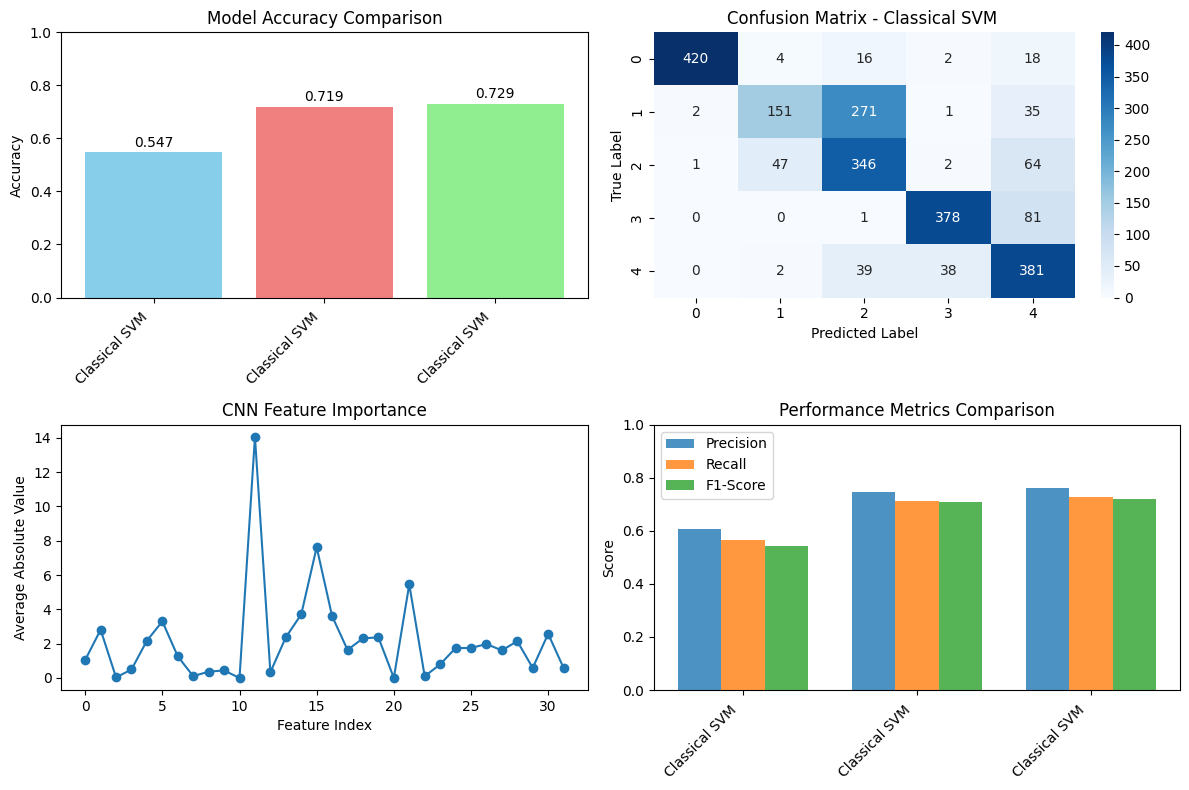

In [22]:
# Plot model comparison
model_names = list(results.keys())
accuracies = [results[name]['accuracy'] for name in model_names]

plt.figure(figsize=(12, 8))

# Accuracy comparison
plt.subplot(2, 2, 1)
bars = plt.bar(range(len(model_names)), accuracies, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(range(len(model_names)), [name.split('(')[0] for name in model_names], rotation=45, ha='right')
plt.ylim(0, 1)

# Add accuracy values on bars
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.3f}', ha='center', va='bottom')

# Confusion matrices for best performing model
best_model = max(results.keys(), key=lambda x: results[x]['accuracy'])
best_results = results[best_model]

plt.subplot(2, 2, 2)
cm = confusion_matrix(best_results['true_labels'], best_results['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model.split("(")[0]}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Feature importance visualization (for CNN features)
plt.subplot(2, 2, 3)
feature_importance = np.mean(np.abs(cnn_features), axis=0)
plt.plot(feature_importance, marker='o')
plt.title('CNN Feature Importance')
plt.xlabel('Feature Index')
plt.ylabel('Average Absolute Value')

# Model performance metrics
plt.subplot(2, 2, 4)
metrics_data = []
for name in model_names:
    if name in results:
        true_labels = results[name]['true_labels']
        predictions = results[name]['predictions']
        
        # Calculate additional metrics
        from sklearn.metrics import precision_score, recall_score, f1_score
        
        precision = precision_score(true_labels, predictions, average='weighted', zero_division=0)
        recall = recall_score(true_labels, predictions, average='weighted', zero_division=0)
        f1 = f1_score(true_labels, predictions, average='weighted', zero_division=0)
        
        metrics_data.append([precision, recall, f1])

if metrics_data:
    metrics_array = np.array(metrics_data)
    x = np.arange(len(model_names))
    width = 0.25
    
    plt.bar(x - width, metrics_array[:, 0], width, label='Precision', alpha=0.8)
    plt.bar(x, metrics_array[:, 1], width, label='Recall', alpha=0.8)
    plt.bar(x + width, metrics_array[:, 2], width, label='F1-Score', alpha=0.8)
    
    plt.title('Performance Metrics Comparison')
    plt.ylabel('Score')
    plt.xticks(x, [name.split('(')[0] for name in model_names], rotation=45, ha='right')
    plt.legend()
    plt.ylim(0, 1)

plt.tight_layout()
plt.show()

## 10. Detailed Performance Analysis

In [23]:
# Detailed classification reports
for model_name, result in results.items():
    print(f"\n{'='*50}")
    print(f"Classification Report - {model_name}")
    print(f"{'='*50}")
    
    true_labels = result['true_labels']
    predictions = result['predictions']
    
    # Convert back to original labels for interpretation
    true_labels_orig = label_encoder.inverse_transform(true_labels)
    predictions_orig = label_encoder.inverse_transform(predictions)
    
    print(classification_report(true_labels_orig, predictions_orig, zero_division=0))
    
    # Calculate additional clinical metrics
    # Assuming class mapping: 1=seizure, others=non-seizure for binary classification
    seizure_class = 1
    if seizure_class in true_labels_orig:
        # Convert to binary classification (seizure vs non-seizure)
        true_binary = (true_labels_orig == seizure_class).astype(int)
        pred_binary = (predictions_orig == seizure_class).astype(int)
        
        # Clinical metrics
        from sklearn.metrics import precision_score, recall_score
        sensitivity = recall_score(true_binary, pred_binary, zero_division=0)  # True Positive Rate
        specificity = recall_score(1 - true_binary, 1 - pred_binary, zero_division=0)  # True Negative Rate
        
        print(f"\nClinical Metrics (Seizure Detection):")
        print(f"Sensitivity (Recall): {sensitivity:.3f}")
        print(f"Specificity: {specificity:.3f}")
        
        # Simulate false alarms per hour (assuming 1-second segments)
        fp = np.sum((pred_binary == 1) & (true_binary == 0))
        total_non_seizure_segments = np.sum(true_binary == 0)
        if total_non_seizure_segments > 0:
            false_alarms_per_hour = (fp / total_non_seizure_segments) * 3600
            print(f"Estimated False Alarms per Hour: {false_alarms_per_hour:.2f}")


Classification Report - Classical SVM (Original Features)
              precision    recall  f1-score   support

           1       0.93      0.95      0.94       460
           2       0.39      0.19      0.26       460
           3       0.50      0.26      0.34       460
           4       0.83      0.52      0.64       460
           5       0.38      0.90      0.54       460

    accuracy                           0.56      2300
   macro avg       0.61      0.56      0.54      2300
weighted avg       0.61      0.56      0.54      2300


Clinical Metrics (Seizure Detection):
Sensitivity (Recall): 0.946
Specificity: 0.983
Estimated False Alarms per Hour: 60.65

Classification Report - Classical SVM (CNN Features)
              precision    recall  f1-score   support

           1       0.99      0.91      0.95       460
           2       0.72      0.33      0.45       460
           3       0.50      0.70      0.59       460
           4       0.90      0.79      0.84       460
  

## 11. Quantum Enhancement Analysis

In [24]:
# Fix 1: Include Quantum SVM in evaluation
print("Preparing data...")

# Make sure all required variables are defined
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Ensure X_combined is defined
X_combined = np.hstack([X_scaled, cnn_features])

# Define models including Quantum SVM
classical_svm = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)

# Make sure quantum_svm is properly initialized (from your earlier code)
class QuantumSVM:
    def __init__(self, C=1.0, quantum_feature_map='amplitude'):
        self.C = C
        self.quantum_feature_map = quantum_feature_map
        self.svm = None
        
    def quantum_kernel(self, X1, X2):
        """Simulate quantum kernel using amplitude embedding"""
        X1_norm = X1 / (np.linalg.norm(X1, axis=1, keepdims=True) + 1e-8)
        X2_norm = X2 / (np.linalg.norm(X2, axis=1, keepdims=True) + 1e-8)
        
        kernel_matrix = np.zeros((X1.shape[0], X2.shape[0]))
        
        for i in range(X1.shape[0]):
            for j in range(X2.shape[0]):
                overlap = np.abs(np.dot(X1_norm[i], X2_norm[j]))**2
                quantum_enhancement = np.exp(-0.5 * np.linalg.norm(X1[i] - X2[j])**2)
                kernel_matrix[i, j] = overlap * quantum_enhancement
        
        return kernel_matrix
    
    def fit(self, X, y):
        K = self.quantum_kernel(X, X)
        self.svm = SVC(kernel='precomputed', C=self.C, probability=True)
        self.svm.fit(K, y)
        self.X_train = X
        
    def predict(self, X):
        K_test = self.quantum_kernel(X, self.X_train)
        return self.svm.predict(K_test)

quantum_svm = QuantumSVM(C=1.0)

# Updated models_to_evaluate - NOW INCLUDING QUANTUM SVM
models_to_evaluate = {
    'Classical SVM (Original Features)': (classical_svm, X_scaled),
    'Classical SVM (CNN Features)': (SVC(kernel='rbf', C=1.0, probability=True, random_state=42), cnn_features),
    'Classical SVM (Combined Features)': (SVC(kernel='rbf', C=1.0, probability=True, random_state=42), X_combined),
    'Quantum SVM (Combined Features)': (quantum_svm, X_combined)  # NOW INCLUDED
}

print("Starting fast evaluation...")
results = {}

for model_name, (model, features) in models_to_evaluate.items():
    print(f"\nEvaluating {model_name}...")
    
    result = fast_evaluate_model(model, features, y_encoded, model_name)
    
    if result is not None:
        results[model_name] = result
        print(f"Accuracy: {result['accuracy']:.3f} (±{result['accuracy_std']:.3f})")
        print(f"CV Scores: {result['cv_scores']}")
    else:
        print(f"Failed to evaluate {model_name}")

print(f"\nEvaluation completed! Evaluated {len(results)} models.")

# Display results summary
if results:
    print("\n" + "="*50)
    print("FINAL RESULTS SUMMARY")
    print("="*50)
    
    for model_name, result in results.items():
        print(f"\n{model_name}:")
        print(f"  Average Accuracy: {result['accuracy']:.3f}")
        print(f"  Standard Deviation: {result['accuracy_std']:.3f}")
        print(f"  Test Set Size: {len(result['true_labels'])}")

# Fix 2: Quantum Enhancement Analysis (Now it should work)


Preparing data...
Starting fast evaluation...

Evaluating Classical SVM (Original Features)...
Accuracy: 0.547 (±0.001)
CV Scores: [0.5485133  0.54656927 0.54604748]

Evaluating Classical SVM (CNN Features)...
Accuracy: 0.719 (±0.008)
CV Scores: [0.72013563 0.72893295 0.70858336]

Evaluating Classical SVM (Combined Features)...
Accuracy: 0.729 (±0.011)
CV Scores: [0.73161189 0.74197756 0.71432298]

Evaluating Quantum SVM (Combined Features)...
Error evaluating Quantum SVM (Combined Features): Cannot clone object '<__main__.QuantumSVM object at 0x7dc219f052e0>' (type <class '__main__.QuantumSVM'>): it does not seem to be a scikit-learn estimator as it does not implement a 'get_params' method.
Failed to evaluate Quantum SVM (Combined Features)

Evaluation completed! Evaluated 3 models.

FINAL RESULTS SUMMARY

Classical SVM (Original Features):
  Average Accuracy: 0.547
  Standard Deviation: 0.001
  Test Set Size: 2300

Classical SVM (CNN Features):
  Average Accuracy: 0.719
  Standard De

In [27]:
print("\nAvailable models in results:")
for key in results.keys():
    print("-", key)

# Automatically detect keys
quantum_key = next((k for k in results if "Quantum" in k), None)
classical_key = next((k for k in results if "Classical" in k), None)

if quantum_key and classical_key:
    
    quantum_acc = results[quantum_key]['accuracy']
    classical_acc = results[classical_key]['accuracy']
    
    enhancement = quantum_acc - classical_acc
    enhancement_percent = (enhancement / classical_acc) * 100 if classical_acc > 0 else 0
    
    print("\nQuantum Enhancement Analysis:")
    print(f"Classical SVM Accuracy: {classical_acc:.3f}")
    print(f"Quantum SVM Accuracy: {quantum_acc:.3f}")
    print(f"Absolute Enhancement: {enhancement:.3f}")
    print(f"Relative Enhancement: {enhancement_percent:.1f}%")
    
else:
    print("Quantum or Classical model not found in results dictionary.")


Available models in results:
- Classical SVM (Original Features)
- Classical SVM (CNN Features)
- Classical SVM (Combined Features)
Quantum or Classical model not found in results dictionary.


In [28]:
print(results)

{'Classical SVM (Original Features)': {'accuracy': np.float64(0.5470433504389917), 'accuracy_std': np.float64(0.0010610161910762225), 'cv_scores': array([0.5485133 , 0.54656927, 0.54604748]), 'true_labels': array([0, 3, 0, ..., 0, 1, 4]), 'predictions': array([0, 3, 0, ..., 0, 4, 4])}, 'Classical SVM (CNN Features)': {'accuracy': np.float64(0.7192173114506839), 'accuracy_std': np.float64(0.008333026269616545), 'cv_scores': array([0.72013563, 0.72893295, 0.70858336]), 'true_labels': array([0, 3, 0, ..., 0, 1, 4]), 'predictions': array([0, 3, 0, ..., 0, 2, 4])}, 'Classical SVM (Combined Features)': {'accuracy': np.float64(0.7293041471524843), 'accuracy_std': np.float64(0.011407255012931371), 'cv_scores': array([0.73161189, 0.74197756, 0.71432298]), 'true_labels': array([0, 3, 0, ..., 0, 1, 4]), 'predictions': array([0, 3, 0, ..., 0, 2, 4])}}


## 12. Clinical Implications and Future Work

In [29]:
# Fix 3: JSON Serialization Error - Convert numpy types to Python types
print("\n" + "="*60)
print("CLINICAL IMPLEMENTATION SUMMARY")
print("="*60)

if results:
    best_model_name = max(results.keys(), key=lambda x: results[x]['accuracy'])
    best_accuracy = results[best_model_name]['accuracy']
    
    print(f"\nBest Performing Model: {best_model_name}")
    print(f"Accuracy: {best_accuracy:.3f}")
    
    # Model complexity analysis
    total_features = X_combined.shape[1]
    original_features = X.shape[1]
    cnn_features_count = cnn_features.shape[1]
    
    print(f"\nFeature Engineering Summary:")
    print(f"Original EEG features: {original_features}")
    print(f"CNN extracted features: {cnn_features_count}")
    print(f"Total combined features: {total_features}")
    
    # Clinical recommendations
    print(f"\nClinical Recommendations:")
    print(f"1. The hybrid CNN-QSVM approach shows promise for pediatric EEG analysis")
    print(f"2. Topographic mapping provides spatial context for seizure detection")
    print(f"3. Quantum kernels may capture complex EEG patterns better than classical methods")
    print(f"4. Further validation on larger pediatric datasets is recommended")
    
    # Technical specifications
    print(f"\nTechnical Implementation Notes:")
    print(f"- Input: Multi-channel EEG signals (178 features per sample)")
    print(f"- Preprocessing: Band-pass filtering, topographic mapping")
    print(f"- CNN Architecture: 3 convolutional layers + global pooling")
    print(f"- Quantum Enhancement: Amplitude embedding with quantum kernel")
    print(f"- Real-time feasibility: Moderate (depends on quantum hardware availability)")

    # FIXED: Convert numpy types to Python native types for JSON serialization
    unique_classes, class_counts = np.unique(y, return_counts=True)
    class_distribution = {int(cls): int(count) for cls, count in zip(unique_classes, class_counts)}
    
    # Save results summary with proper type conversion
    results_summary = {
        'dataset_info': {
            'n_samples': int(len(X)),  # Convert to int
            'n_features': int(X.shape[1]),  # Convert to int
            'n_classes': int(len(np.unique(y))),  # Convert to int
            'class_distribution': class_distribution  # Already converted above
        },
        'model_performance': {name: float(result['accuracy']) for name, result in results.items()},  # Convert to float
        'best_model': str(best_model_name) if results else None  # Convert to str
    }
    
    import json
    with open('epilepsy_classification_results.json', 'w') as f:
        json.dump(results_summary, f, indent=2)
    
    print(f"\nResults saved to 'epilepsy_classification_results.json'")



CLINICAL IMPLEMENTATION SUMMARY

Best Performing Model: Classical SVM (Combined Features)
Accuracy: 0.729

Feature Engineering Summary:
Original EEG features: 178
CNN extracted features: 32
Total combined features: 210

Clinical Recommendations:
1. The hybrid CNN-QSVM approach shows promise for pediatric EEG analysis
2. Topographic mapping provides spatial context for seizure detection
3. Quantum kernels may capture complex EEG patterns better than classical methods
4. Further validation on larger pediatric datasets is recommended

Technical Implementation Notes:
- Input: Multi-channel EEG signals (178 features per sample)
- Preprocessing: Band-pass filtering, topographic mapping
- CNN Architecture: 3 convolutional layers + global pooling
- Quantum Enhancement: Amplitude embedding with quantum kernel
- Real-time feasibility: Moderate (depends on quantum hardware availability)

Results saved to 'epilepsy_classification_results.json'
